# Slope limiters: minmod, Van Leer, MC and Van Albada with the TVD2 and UNO2 reconstructions

We solve the advection equation $u_t + u_x = 0$ on $(0, 1)$ with periodic conditions. The initial condition is a square wave on $(0.1, 0.3)$ and a smooth Gaussian hump centered at $x = 0.65$. After one period, at $t = 1$, the exact solution is the initial condition again.

We use DG elements of degree 1, the upwind flux and the third-order SSP Runge-Kutta method with slope limiters. `fd.SlopeLimiter(V, limiter, reconstruction)` keeps the mean $W_j$ of every element and replaces its slope by a limited slope $S_j$ of the means, so the end values are $W_j \pm \tfrac12 S_j$.

- **TVD2** applies the limiter to the differences of the means, $S_j = \phi(r_j)\, d_{j+1/2} W$, with $r_j = d_{j-1/2} W / d_{j+1/2} W$ and $d_{j+1/2} W = W_{j+1} - W_j$.
- **UNO2** applies it to the differences corrected by the second differences, $S_j = \phi(r_j)\, S_j^+$, with $r_j = S_j^- / S_j^+$ and $S_j^\pm = d_{j\pm1/2} W \mp \tfrac12 m\left(D_{j}W, D_{j\pm1}W\right)$, where $D_j W = W_{j+1} - 2W_j + W_{j-1}$ and $m$ is the minmod function.

| `limiter` | | $\phi(r)$ |
|---|---|---|
| `"minmod"` | minmod | $\max\left(0, \min(1, r)\right)$ |
| `"vanleer"` | Van Leer | $(r + \lvert r\rvert)/(1 + \lvert r\rvert)$ |
| `"mc"` | monotonized central | $\max\left(0, \min\left((1 + r)/2, 2, 2r\right)\right)$ |
| `"vanalbada"` | Van Albada | $(r + r^2)/(1 + r^2)$ |

TVD2 flattens smooth extrema, where it is only first order. UNO2 is second order there too.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import D, dx, dS, jump

## The semidiscretization

**Elements and fluxes.** We divide $(0, 1)$ into $n$ elements $I_j = (x_{j-1/2}, x_{j+1/2})$ of width $h = 1/n$, and let $V_h$ be the functions that are linear on every $I_j$ and may jump at the vertices. A function of $V_h$ has two values at the vertex $x_{j+1/2}$, the value $u^-_{j+1/2}$ from $I_j$ and $u^+_{j+1/2}$ from $I_{j+1}$.

We write the equation as $u_t + f(u)_x = 0$ with the flux $f(u) = u$, multiply it by a test function $v \in V_h$ that is zero outside $I_j$, and integrate by parts over $I_j$. At the two ends of $I_j$ the flux $f(u)$ is replaced by a numerical flux $\hat F_{j\pm1/2} = \hat F\left(u^-_{j\pm1/2}, u^+_{j\pm1/2}\right)$, which gives

$$\int_{I_j} u_t\, v\,dx = \int_{I_j} u\, v_x\,dx - \hat F_{j+1/2}\, v\left(x_{j+1/2}^-\right) + \hat F_{j-1/2}\, v\left(x_{j-1/2}^+\right).$$

The wave speed is 1, so we take the upwind flux, the value from the left,

$$\hat F(u^-, u^+) = u^-.$$

It is also the central (Lax-Friedrichs) flux, $\tfrac12\left(f(u^-) + f(u^+)\right) - \tfrac12 \alpha\left(u^+ - u^-\right)$ with $\alpha = 1$.

**The DG form.** Adding the equations of all the elements, each vertex collects $\hat F_{j+1/2}$ times the jump $[v]_{j+1/2} = v^-_{j+1/2} - v^+_{j+1/2}$. With periodic conditions the vertex $x = 0 = 1$ is one of them. So $u_h \in V_h$ solves

$$\left(u_{h,t}, v\right) = \left(u_h, v_x\right) - \sum_{j=1}^{n} u^-_{j+1/2}\, [v]_{j+1/2} \qquad \text{for every } v \in V_h.$$

In FEMd the sum over the vertices is the measure `dS`, $u^-$ is `w('-')` and $[v]$ is `jump(v)`, so the right-hand side is `w*D(v)*dx - w('-')*jump(v)*dS`. Writing $u_h = \sum_k c_k N_k$ in the Legendre basis of `DGSpace`, this is the system of ordinary differential equations

$$M\, c'(t) = R(c), \qquad M_{ik} = (N_k, N_i),$$

with a diagonal mass matrix $M$.


**Time stepping.** The third-order SSP Runge-Kutta method of Shu and Osher, the second tableau of (3.15) in the paper, with the limiter $\Lambda$ applied after every stage,

$$\begin{aligned}
c^{(1)} &= \Lambda\left(c^n + \Delta t\, M^{-1} R(c^n)\right),\\
c^{(2)} &= \Lambda\left(\tfrac34 c^n + \tfrac14\left(c^{(1)} + \Delta t\, M^{-1} R(c^{(1)})\right)\right),\\
c^{n+1} &= \Lambda\left(\tfrac13 c^n + \tfrac23\left(c^{(2)} + \Delta t\, M^{-1} R(c^{(2)})\right)\right).
\end{aligned}$$

This is `fd.SSPRK(M, R, dt, order=3, limiter=lim)`. We take $\Delta t = 0.1\,h$ and $n = 200$ elements. The initial condition is written with `fd.sign` and `fd.exp`.

In [2]:
n = 200
V = fd.DGSpace(np.linspace(0, 1, n + 1), 1, bc="periodic")
u, v = fd.TrialFunction(V), fd.TestFunction(V)
w = fd.Function(V)

M = fd.form(u * v * dx)
R = fd.form(w * D(v) * dx - w('-') * jump(v) * dS)     # (w, v_x) - sum over the vertices of w^- [v]

x = fd.x
u0 = 0.5 * (fd.sign(x - 0.1) - fd.sign(x - 0.3)) + fd.exp(-300 * (x - 0.65) ** 2)

h = 1 / n
dt = 1 / np.ceil(1 / (0.1 * h))                       # 0.1 h, and 1/dt steps exactly
nsteps = round(1 / dt)

xs = np.linspace(0, 1, 2001)
exact = np.where((xs > 0.1) & (xs < 0.3), 1.0, 0.0) + np.exp(-300 * (xs - 0.65) ** 2)

**One period with every limiter and both reconstructions.** For each choice we start again from $u_0$, apply the limiter once, and take the steps.

In [3]:
limiters = ["minmod", "vanleer", "mc", "vanalbada"]
results = {}
for limiter in limiters:
    for reconstruction in ["tvd2", "uno2"]:
        w.project(u0)
        lim = fd.SlopeLimiter(V, limiter, reconstruction)
        lim(w)
        rk = fd.SSPRK(M, R, dt, order=3, limiter=lim)
        for k in range(nsteps):
            rk.step(w)
        results[limiter, reconstruction] = w(xs)

hump = (xs > 0.5) & (xs < 0.8)
print(f"{'limiter':>10} {'':>5} {'min':>8} {'max':>8} {'top of hump':>12}")
for (limiter, reconstruction), values in results.items():
    print(f"{limiter:>10} {reconstruction:>5} {values.min():8.3f} {values.max():8.3f} {values[hump].max():12.3f}")

   limiter            min      max  top of hump
    minmod  tvd2    0.000    0.998        0.838
    minmod  uno2   -0.000    1.000        0.983
   vanleer  tvd2    0.000    1.000        0.924
   vanleer  uno2   -0.169    1.169        0.997
        mc  tvd2    0.000    1.000        0.953
        mc  uno2   -0.209    1.209        0.997
 vanalbada  tvd2    0.000    1.000        0.892
 vanalbada  uno2   -0.000    1.000        0.997


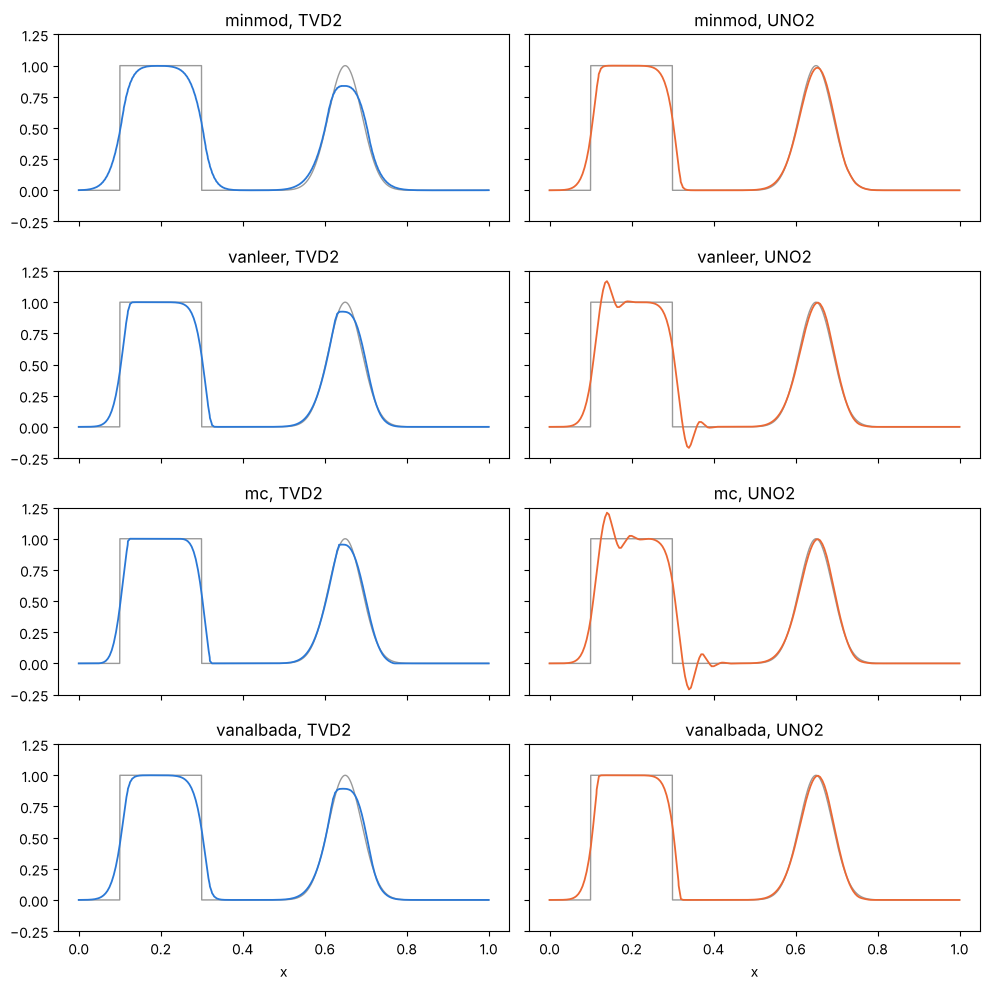

In [4]:
fig, axs = plt.subplots(4, 2, figsize=(10, 10), sharex=True, sharey=True)
for i, limiter in enumerate(limiters):
    for j, reconstruction in enumerate(["tvd2", "uno2"]):
        ax = axs[i, j]
        ax.plot(xs, exact, color="#9a9a9a", lw=1)
        ax.plot(xs, results[limiter, reconstruction], color=["#2a78d6", "#eb6834"][j], lw=1.3)
        ax.set_title(f"{limiter}, {reconstruction.upper()}")
        ax.set_ylim(-0.25, 1.25)
axs[-1, 0].set_xlabel("x"); axs[-1, 1].set_xlabel("x")
plt.tight_layout()
plt.show()